In [1]:
!pip install mlxtend

INFO: pip is looking at multiple versions of mlxtend to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ----------------------- -


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import mlxtend

print("mlxtend installed successfully")

mlxtend installed successfully


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [4]:
import pandas as pd

df = pd.read_csv("Task11_dataset.csv")

df.head()

,Student_ID,Skill_Name,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency,Skill_Category,Proficiency_Level
0,S001,Data Analysis,83,83,65,170,96,5,Analytics,Advanced
1,S001,Tableau,42,48,78,160,98,29,Visualization,Beginner
2,S001,Computer Vision,53,90,57,63,83,27,AI,Intermediate
3,S001,Cloud Computing,86,63,51,22,91,12,Cloud,Advanced
4,S001,Statistics,92,97,75,95,81,17,Analytics,Advanced


In [5]:
print(df.shape)

(2000, 10)


In [6]:
df.describe()

,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,68.997000,70.168500,75.140500,103.275000,74.601000,15.78800
std,17.124679,17.755245,14.507481,54.779693,14.787465,8.67852
min,40.000000,40.000000,50.000000,10.000000,50.000000,1.00000
25%,54.000000,55.000000,63.000000,56.000000,62.000000,8.00000
50%,68.000000,70.000000,75.000000,102.000000,75.000000,16.00000
75%,84.000000,85.000000,88.000000,150.000000,87.000000,23.00000
max,99.000000,100.000000,100.000000,200.000000,100.000000,30.00000


In [7]:
df.isnull().sum()

Student_ID                      0
Skill_Name                      0
Skill_Score                     0
Assessment_Score                0
Course_Completion_Percentage    0
Learning_Hours                  0
Assignment_Completion_Rate      0
Login_Frequency                 0
Skill_Category                  0
Proficiency_Level               0
dtype: int64

In [8]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [9]:
df_original = df.copy()

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Skill_Name'] = le.fit_transform(df['Skill_Name'])
df['Skill_Category'] = le.fit_transform(df['Skill_Category'])
df['Proficiency_Level'] = le.fit_transform(df['Proficiency_Level'])

df.head()

,Student_ID,Skill_Name,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency,Skill_Category,Proficiency_Level
0,S001,5,83,83,65,170,96,5,1,0
1,S001,18,42,48,78,160,98,29,8,1
2,S001,3,53,90,57,63,83,27,0,2
3,S001,2,86,63,51,22,91,12,2,0
4,S001,17,92,97,75,95,81,17,1,0


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df[['Skill_Score',
        'Assessment_Score',
        'Learning_Hours',
        'Login_Frequency']]
)

print(scaled_data[:5])

[[ 0.81791328  0.72286859  1.21836549 -1.24337994]
 [-1.57689101 -1.24887288  1.03577043  1.52276008]
 [-0.93438254  1.11721689 -0.73540157  1.29224841]
 [ 0.99314286 -0.40384082 -1.48404129 -0.4365891 ]
 [ 1.34360203  1.51156518 -0.15109741  0.13969007]]


In [12]:
import os

os.makedirs("visualizations", exist_ok=True)

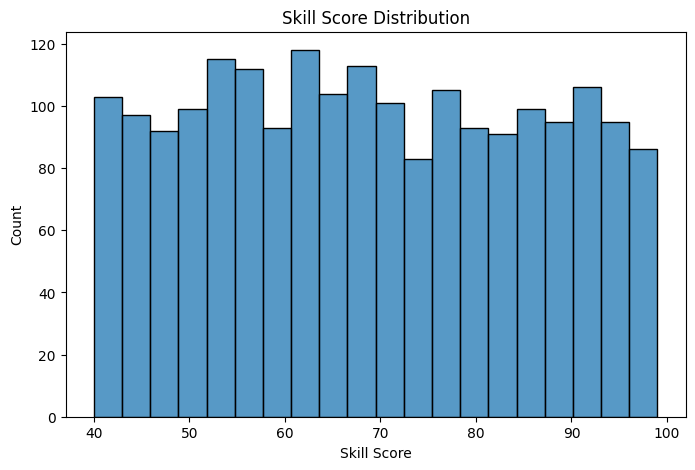

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['Skill_Score'], bins=20)

plt.title("Skill Score Distribution")
plt.xlabel("Skill Score")
plt.ylabel("Count")

plt.savefig("visualizations/skill_distribution.png")

plt.show()

In [14]:
df['Skill_Gap'] = 100 - df['Skill_Score']

df[['Skill_Score', 'Skill_Gap']].head()

,Skill_Score,Skill_Gap
0,83,17
1,42,58
2,53,47
3,86,14
4,92,8


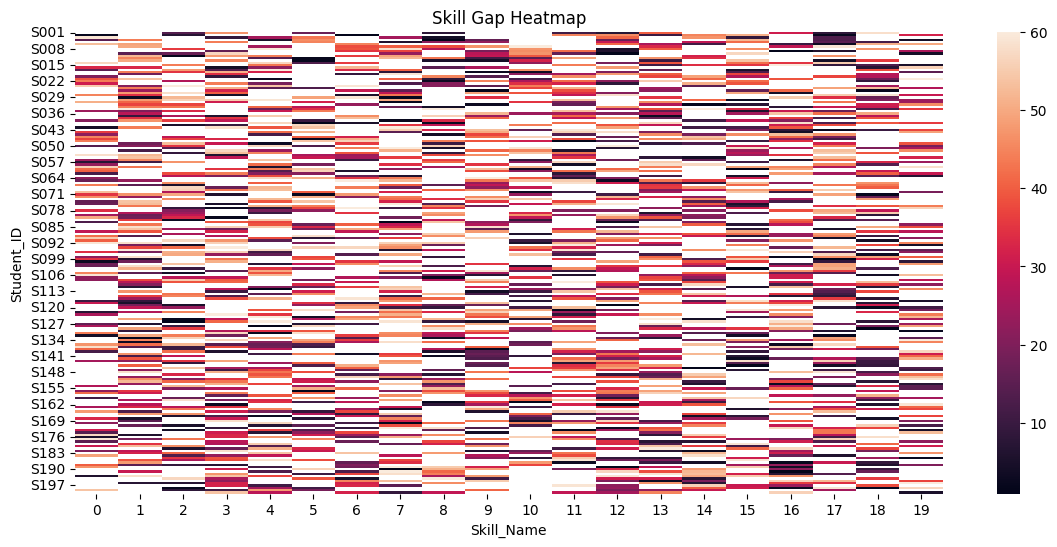

In [15]:
pivot = df.pivot_table(
    values='Skill_Gap',
    index='Student_ID',
    columns='Skill_Name',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))

sns.heatmap(pivot)

plt.title("Skill Gap Heatmap")

plt.savefig(
    "visualizations/skill_gap_heatmap.png"
)

plt.show()

In [16]:
features = df[
    [
        'Skill_Score',
        'Assessment_Score',
        'Learning_Hours',
        'Login_Frequency'
    ]
]

features.head()

,Skill_Score,Assessment_Score,Learning_Hours,Login_Frequency
0,83,83,170,5
1,42,48,160,29
2,53,90,63,27
3,86,63,22,12
4,92,97,95,17


In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(features)

df.head()

,Student_ID,Skill_Name,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency,Skill_Category,Proficiency_Level,Skill_Gap,Cluster
0,S001,5,83,83,65,170,96,5,1,0,17,1
1,S001,18,42,48,78,160,98,29,8,1,58,1
2,S001,3,53,90,57,63,83,27,0,2,47,0
3,S001,2,86,63,51,22,91,12,2,0,14,0
4,S001,17,92,97,75,95,81,17,1,0,8,2


In [18]:
print(df['Cluster'].value_counts())

Cluster
0    720
2    650
1    630
Name: count, dtype: int64


In [19]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    features,
    df['Cluster']
)

print("Silhouette Score:", score)

Silhouette Score: 0.35496655687809425


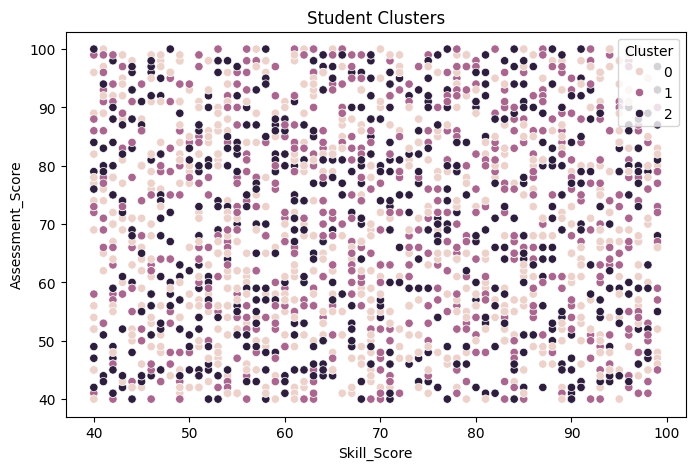

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Skill_Score',
    y='Assessment_Score',
    hue='Cluster'
)

plt.title("Student Clusters")

plt.savefig(
    "visualizations/cluster_plot.png"
)

plt.show()

In [21]:
cluster_mean = df.groupby(
    'Cluster'
)['Skill_Score'].mean()

print(cluster_mean)

Cluster
0    68.338889
1    69.939683
2    68.812308
Name: Skill_Score, dtype: float64


In [22]:
cluster_names = {
    0:'Beginner',
    1:'Intermediate',
    2:'Advanced'
}

df['Learner_Group'] = df[
    'Cluster'
].map(cluster_names)

df.head()

,Student_ID,Skill_Name,Skill_Score,Assessment_Score,Course_Completion_Percentage,Learning_Hours,Assignment_Completion_Rate,Login_Frequency,Skill_Category,Proficiency_Level,Skill_Gap,Cluster,Learner_Group
0,S001,5,83,83,65,170,96,5,1,0,17,1,Intermediate
1,S001,18,42,48,78,160,98,29,8,1,58,1,Intermediate
2,S001,3,53,90,57,63,83,27,0,2,47,0,Beginner
3,S001,2,86,63,51,22,91,12,2,0,14,0,Beginner
4,S001,17,92,97,75,95,81,17,1,0,8,2,Advanced


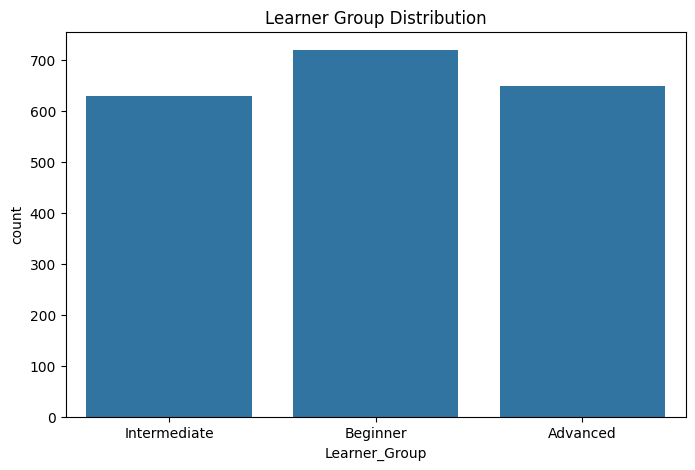

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Learner_Group',
    data=df
)

plt.title(
    "Learner Group Distribution"
)

plt.show()

In [24]:
#Q1
top_skills = df_original.groupby(
    'Skill_Name'
)['Skill_Score'].mean()

top_skills.sort_values(
    ascending=False
).head(10)

Skill_Name
Tableau             74.500000
Java                71.786517
Python              70.916667
Excel               70.531915
Machine Learning    70.090909
Statistics          69.730769
Data Analysis       69.451613
Cloud Computing     69.418367
NLP                 69.157407
SQL                 69.067961
Name: Skill_Score, dtype: float64

In [25]:
#2Q
gap = df_original.groupby(
    'Skill_Name'
)['Skill_Score'].mean()

(100-gap).sort_values(
    ascending=False
).head(10)

Skill_Name
Deep Learning      35.046729
Linux              33.365385
Cyber Security     33.046729
C++                32.389831
Git                32.181818
Computer Vision    31.943925
Algorithms         31.586957
Data Structures    31.533333
Web Development    31.252874
Power BI           31.208333
Name: Skill_Score, dtype: float64

In [26]:
basket = pd.crosstab(
    df_original['Student_ID'],
    df_original['Skill_Name']
)

basket = basket > 0

basket.head()

Skill_Name,Algorithms,C++,Cloud Computing,Computer Vision,Cyber Security,Data Analysis,Data Structures,Deep Learning,Excel,Git,Java,Linux,Machine Learning,NLP,Power BI,Python,SQL,Statistics,Tableau,Web Development
Student_ID,,,,,,,,,,,,,,,,,,,,
S001,False,False,True,True,False,True,False,False,True,False,False,True,True,True,False,False,True,True,True,False
S002,True,False,True,False,False,False,True,False,False,False,False,True,True,True,True,True,False,True,False,True
S003,True,False,False,True,True,True,False,True,True,False,False,False,True,False,True,True,False,True,False,False
S004,True,True,False,False,True,True,False,False,True,True,False,False,True,False,False,True,False,True,False,True
S005,False,False,False,True,False,True,False,True,True,True,False,False,True,False,True,True,False,True,True,False


In [27]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

frequent_itemsets = apriori(
    basket,
    min_support=0.10,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.460,(Algorithms)
1,0.590,(C++)
2,0.490,(Cloud Computing)
3,0.535,(Computer Vision)
4,0.535,(Cyber Security)


In [28]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.5
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Algorithms),(C++),0.460,0.590,0.26,0.565217,0.957996,1.0,-0.0114,0.943000,-0.075099,0.329114,-0.060445,0.502948
1,(Algorithms),(Computer Vision),0.460,0.535,0.23,0.500000,0.934579,1.0,-0.0161,0.930000,-0.114754,0.300654,-0.075269,0.464953
2,(Data Analysis),(Algorithms),0.465,0.460,0.24,0.516129,1.122020,1.0,0.0261,1.116000,0.203271,0.350365,0.103943,0.518934
3,(Algorithms),(Data Analysis),0.460,0.465,0.24,0.521739,1.122020,1.0,0.0261,1.118636,0.201389,0.350365,0.106054,0.518934
4,(Algorithms),(Machine Learning),0.460,0.550,0.25,0.543478,0.988142,1.0,-0.0030,0.985714,-0.021739,0.328947,-0.014493,0.499012


In [29]:
# 6Q
rules[['antecedents',
       'consequents',
       'support',
       'confidence']].head(10)

,antecedents,consequents,support,confidence
0,(Algorithms),(C++),0.260,0.565217
1,(Algorithms),(Computer Vision),0.230,0.500000
2,(Data Analysis),(Algorithms),0.240,0.516129
3,(Algorithms),(Data Analysis),0.240,0.521739
4,(Algorithms),(Machine Learning),0.250,0.543478
5,(Algorithms),(NLP),0.240,0.521739
6,(Algorithms),(Power BI),0.235,0.510870
7,(Algorithms),(Statistics),0.240,0.521739
8,(Cloud Computing),(C++),0.265,0.540816
9,(C++),(Computer Vision),0.315,0.533898


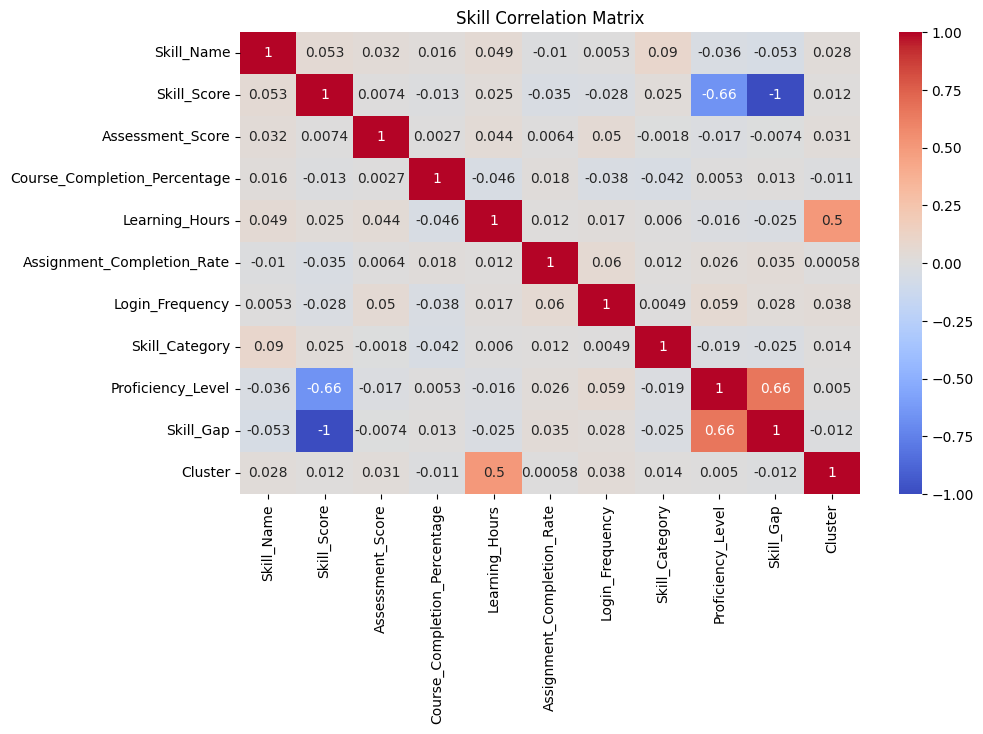

In [30]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Skill Correlation Matrix")

plt.savefig(
    "visualizations/correlation_matrix.png"
)

plt.show()

In [31]:
X = df[
    [
        'Assessment_Score',
        'Learning_Hours',
        'Assignment_Completion_Rate',
        'Login_Frequency'
    ]
]

y = df['Skill_Score']

In [32]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train,y_train)

predictions = rf.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 14.9826
MSE: 316.6689455
R2: -0.11072277872077718


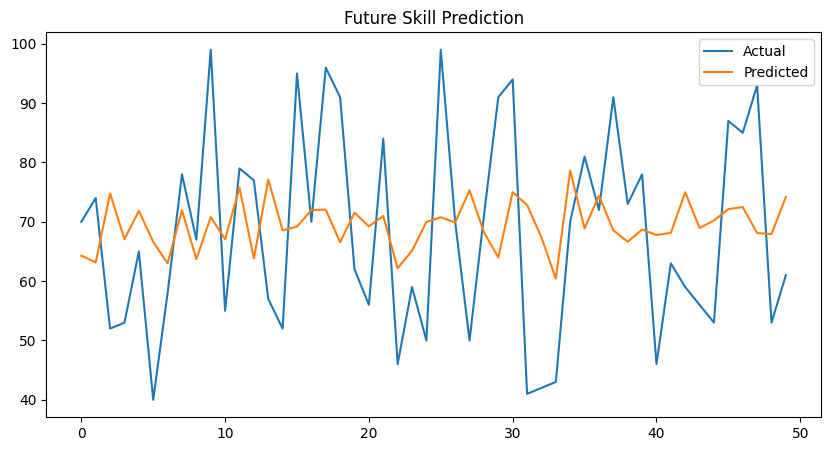

In [35]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:50],
    label='Actual'
)

plt.plot(
    predictions[:50],
    label='Predicted'
)

plt.legend()

plt.title(
    "Future Skill Prediction"
)

plt.savefig(
    "visualizations/future_prediction.png"
)

plt.show()

In [36]:
#5Q
def recommend_learning(score):

    if score < 50:
        return "Beginner Path"

    elif score < 75:
        return "Intermediate Path"

    else:
        return "Advanced Path"

df['Recommendation'] = df[
    'Skill_Score'
].apply(recommend_learning)

df[['Skill_Score',
    'Recommendation']].head()

,Skill_Score,Recommendation
0,83,Advanced Path
1,42,Beginner Path
2,53,Intermediate Path
3,86,Advanced Path
4,92,Advanced Path


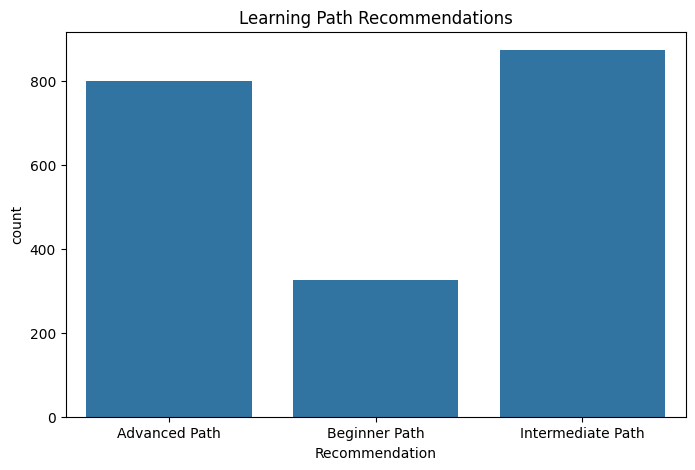

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Recommendation',
    data=df
)

plt.title(
    "Learning Path Recommendations"
)

plt.savefig(
    "visualizations/recommendation_dashboard.png"
)

plt.show()